# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Reading a local CSV File

In [2]:
df = pd.read_csv('wine_data.csv', usecols=[0,1,2])
df.columns=['ClassLabel', 'Alcohol', 'MalicAcid']
df.index = df.index + 1
df.head()

,ClassLabel,Alcohol,MalicAcid
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
5,1,14.20,1.76


# 3. Analysis of columns using KDE Plots

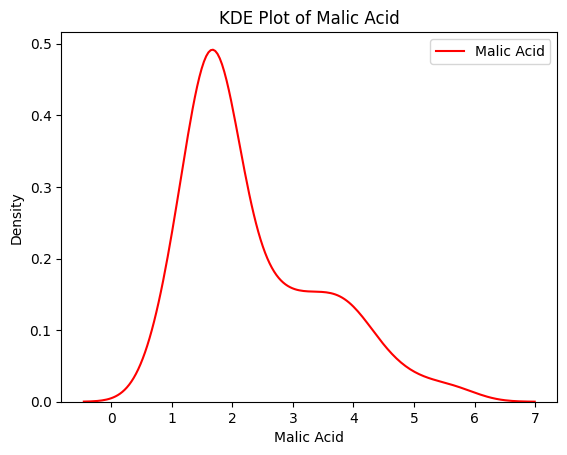

In [3]:
sns.kdeplot(df['MalicAcid'], label='Malic Acid', color='red')
plt.title("KDE Plot of Malic Acid")
plt.xlabel("Malic Acid")
plt.ylabel("Density")
plt.legend()
plt.show()

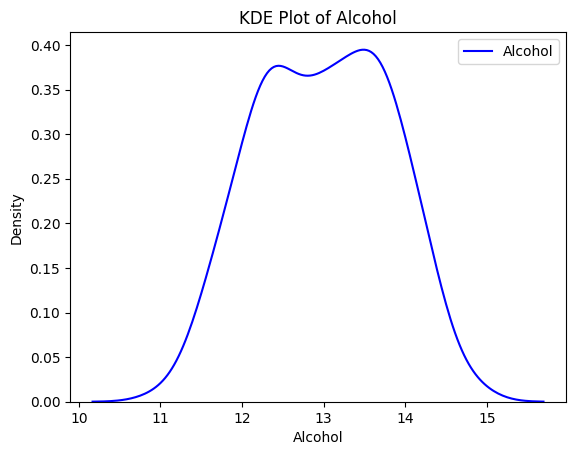

In [4]:
sns.kdeplot(df['Alcohol'], label='Alcohol', color='blue')
plt.title("KDE Plot of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.legend()
plt.show()

<Axes: xlabel='Alcohol', ylabel='MalicAcid'>

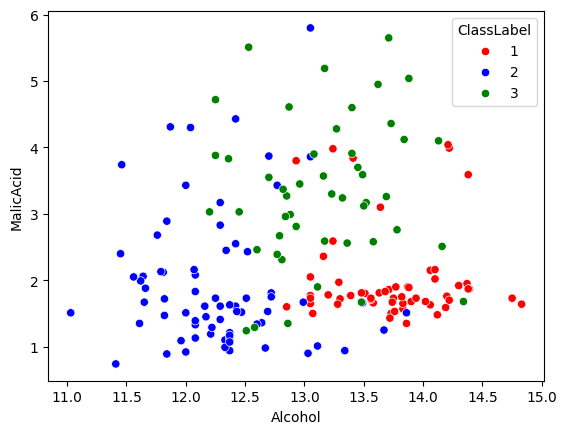

In [5]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'], y=df['MalicAcid'], hue=df['ClassLabel'], palette=color_dict)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('ClassLabel', axis=1),
                                                    df['ClassLabel'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((123, 2), (54, 2))

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [9]:
np.round(X_train.describe(), 2)

,Alcohol,MalicAcid
count,123.00,123.00
mean,12.98,2.33
std,0.78,1.17
min,11.03,0.89
25%,12.37,1.56
50%,13.05,1.83
75%,13.62,3.08
max,14.75,5.80


In [10]:
np.round(X_train_scaled.describe(), 2)

,Alcohol,MalicAcid
count,123.00,123.00
mean,0.52,0.29
std,0.21,0.24
min,0.00,0.00
25%,0.36,0.14
50%,0.54,0.19
75%,0.70,0.45
max,1.00,1.00


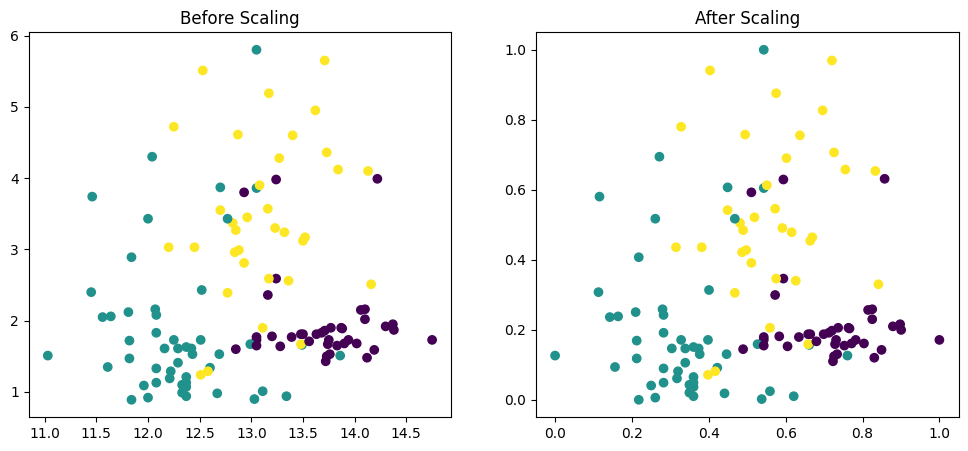

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['MalicAcid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['MalicAcid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

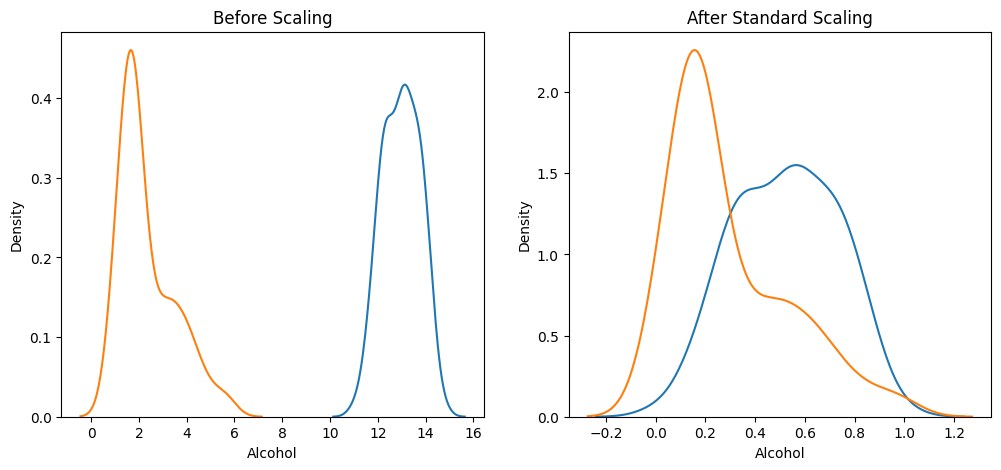

In [12]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['MalicAcid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['MalicAcid'], ax=ax2)
plt.show()

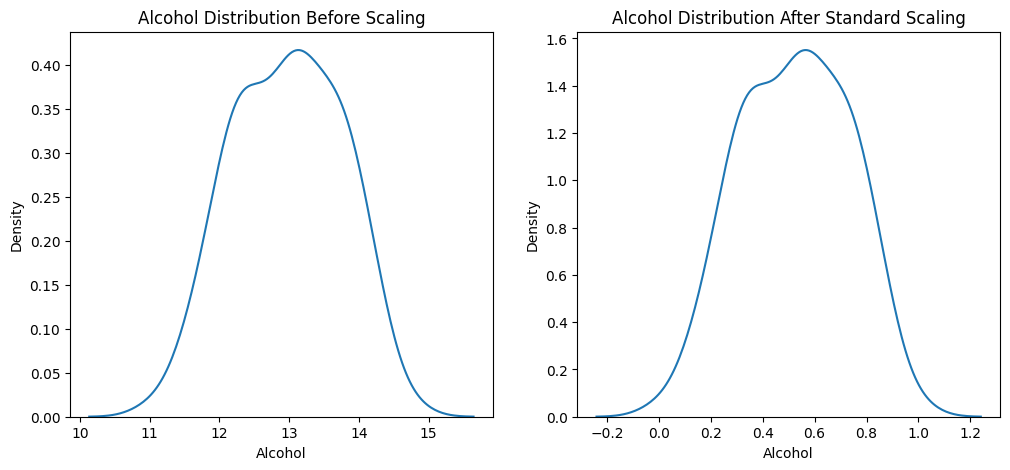

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

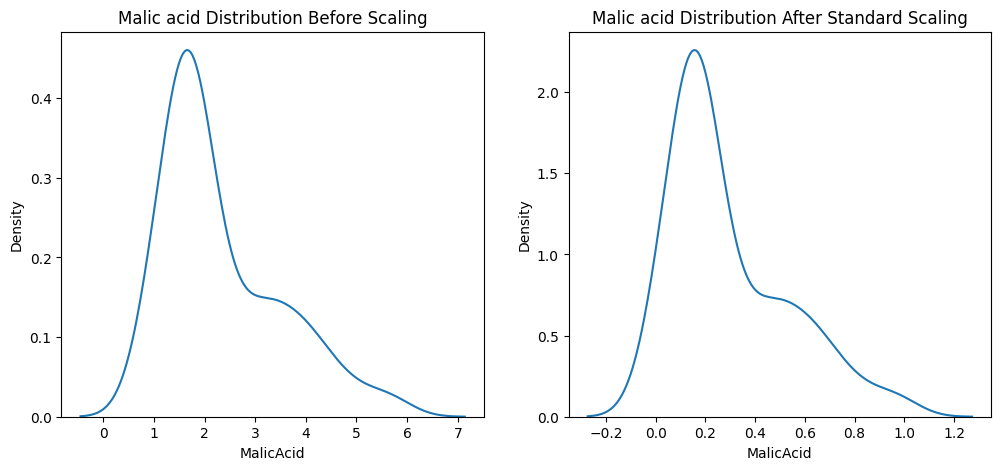

In [14]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['MalicAcid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['MalicAcid'], ax=ax2)
plt.show()